# 08 - Model comparison

Brings together every prediction file in `results/predictions/` (three baselines from notebook 06, up to four transformers from notebook 07) and produces the Results-chapter material:

- Table 12: macro-F1 with bootstrap 95% CI and dissatisfied-class recall for every model
- Table 13: macro-F1 within the English and Arabic strata and the gap
- Table 14: McNemar paired comparisons for the four pre-registered pairs
- RQ1 tests: exact binomial against the majority-class rate, macro-F1 by length band
- Figure 5 (confusion matrix of the best model) and Figure 6 (ROC curves)

Transformer rows are filled in automatically once their prediction files are present; until then they are reported as awaiting.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# make src importable when the kernel starts inside notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
from src import config
from src.io import ensure_dirs, save_table, update_metrics, read_metrics
ensure_dirs()

In [2]:
from src.io import load_predictions
from src.evaluation import macro_f1_report, per_language_metrics, per_segment_metrics, confusion
from src.stats import mcnemar_test, bootstrap_macro_f1, binomial_vs_baseline
from sklearn.metrics import roc_curve, roc_auc_score

test = pd.read_parquet(config.SPLIT_FILES["test"])
preds = load_predictions()
for k, p in preds.items():
    assert set(p.review_id) <= set(test.review_id), k
    preds[k] = p.merge(test[["review_id", "language", "platform", "app_name", "length_band", "word_count"]], on="review_id")
available = [k for k in config.MODEL_DISPLAY if k in preds]
missing = [k for k in config.MODEL_DISPLAY if k not in preds]
print("available:", available)
print("awaiting :", missing)

available: ['tfidf_lr', 'tfidf_svm', 'tfidf_nb', 'xlmr', 'mbert', 'arabert', 'marbert']
awaiting : []


## Table 12 - headline comparison

In [3]:
rows = []
for k in config.MODEL_DISPLAY:
    if k not in preds:
        rows.append({"key": k, "model": config.MODEL_DISPLAY[k], "status": "awaiting notebook 07 output"}); continue
    p = preds[k]
    rep = macro_f1_report(p.y_true, p.y_pred, p.p_dissat)
    boot = bootstrap_macro_f1(p.y_true, p.y_pred)
    rows.append({"key": k, "model": config.MODEL_DISPLAY[k], "status": "scored", "n_test": rep["n"],
                 "macro_f1": rep["macro_f1"], "ci_low": boot["ci_low"], "ci_high": boot["ci_high"],
                 "recall_dissatisfied": rep["recall_Dissatisfied"], "recall_satisfied": rep["recall_Satisfied"],
                 "precision_dissatisfied": rep["precision_Dissatisfied"], "auc": rep["auc"],
                 "accuracy_secondary": rep["accuracy_secondary"]})
t12 = pd.DataFrame(rows)
save_table(t12, "table12_model_performance")
t12.round(4)

,key,model,status,n_test,macro_f1,ci_low,ci_high,recall_dissatisfied,recall_satisfied,precision_dissatisfied,auc,accuracy_secondary
0,tfidf_lr,TF-IDF + logistic regression,scored,7340,0.9083,0.9017,0.9149,0.9326,0.8813,0.9077,0.9605,0.9098
1,tfidf_svm,TF-IDF + linear SVM,scored,7340,0.9107,0.9042,0.9171,0.9441,0.8727,0.9027,0.9605,0.9124
2,tfidf_nb,TF-IDF + multinomial naive Bayes,scored,7340,0.8904,0.8832,0.8976,0.9434,0.8301,0.8741,0.9448,0.8931
3,xlmr,XLM-RoBERTa (base),scored,7340,0.9273,0.9213,0.9330,0.9510,0.9003,0.9227,0.9727,0.9285
4,mbert,Multilingual BERT,scored,7340,0.9184,0.9120,0.9246,0.9529,0.8789,0.9078,0.9687,0.9200
5,arabert,AraBERT,scored,1781,0.9078,0.8944,0.9215,0.9339,0.8906,0.8632,0.9639,0.9090
6,marbert,MARBERT,scored,1781,0.9145,0.9009,0.9273,0.9339,0.9023,0.8761,0.9651,0.9158


In [4]:
# best classical baseline and best model overall, by macro-F1 on the full test set
scored = t12[t12.status == "scored"].set_index("key")
bilingual = [k for k in scored.index if k in config.CLASSICAL_MODELS or config.TRANSFORMER_MODELS.get(k, ("", "", ""))[2] == "bilingual"]
best_classical = scored.loc[[k for k in scored.index if k in config.CLASSICAL_MODELS], "macro_f1"].idxmax()
best_overall = scored.loc[bilingual, "macro_f1"].idxmax()
print("best classical:", config.MODEL_DISPLAY[best_classical], "| best overall (full test set):", config.MODEL_DISPLAY[best_overall])

best classical: TF-IDF + linear SVM | best overall (full test set): XLM-RoBERTa (base)


## Table 13 - language-stratified performance

In [5]:
rows = []
for k in available:
    p = preds[k]
    pl = per_language_metrics(p, p.y_true, p.y_pred).set_index("language")
    en = pl.loc["English", "macro_f1"] if "English" in pl.index else np.nan
    ar_sub = p[p.language == "Arabic"]
    ar_boot = bootstrap_macro_f1(ar_sub.y_true, ar_sub.y_pred)
    rows.append({"key": k, "model": config.MODEL_DISPLAY[k], "macro_f1_english": en,
                 "n_english": int((p.language == "English").sum()),
                 "macro_f1_arabic": ar_boot["macro_f1"], "arabic_ci_low": ar_boot["ci_low"], "arabic_ci_high": ar_boot["ci_high"],
                 "n_arabic": ar_boot["n"], "gap_en_minus_ar": (en - ar_boot["macro_f1"]) if not np.isnan(en) else np.nan})
t13 = pd.DataFrame(rows)
save_table(t13, "table13_language_stratified")
t13.round(4)

,key,model,macro_f1_english,n_english,macro_f1_arabic,arabic_ci_low,arabic_ci_high,n_arabic,gap_en_minus_ar
0,tfidf_lr,TF-IDF + logistic regression,0.9145,5559,0.8798,0.8645,0.8954,1781,0.0347
1,tfidf_svm,TF-IDF + linear SVM,0.9168,5559,0.8831,0.8676,0.8987,1781,0.0336
2,tfidf_nb,TF-IDF + multinomial naive Bayes,0.9002,5559,0.8424,0.8240,0.8600,1781,0.0578
3,xlmr,XLM-RoBERTa (base),0.9313,5559,0.9086,0.8943,0.9222,1781,0.0227
4,mbert,Multilingual BERT,0.9255,5559,0.8891,0.8742,0.9040,1781,0.0364
5,arabert,AraBERT,NaN,0,0.9078,0.8944,0.9215,1781,NaN
6,marbert,MARBERT,NaN,0,0.9145,0.9009,0.9273,1781,NaN


## Table 14 - McNemar paired comparisons

In [6]:
def paired(a, b, subset):
    pa, pb = preds[a], preds[b]
    m = pa.merge(pb, on="review_id", suffixes=("_a", "_b"))
    if subset != "full":
        m = m[m.language_a == subset]
    return m

rows = []
for a, b, subset, label in config.MCNEMAR_PAIRS:
    b_key = best_classical if b == "best_classical" else b
    if a not in preds or b_key not in preds:
        rows.append({"comparison": label, "model_a": a, "model_b": b_key, "subset": subset, "status": "awaiting notebook 07 output"}); continue
    m = paired(a, b_key, subset)
    mc = mcnemar_test(m.y_true_a, m.y_pred_a, m.y_pred_b)
    fa = bootstrap_macro_f1(m.y_true_a, m.y_pred_a)["macro_f1"]
    fb = bootstrap_macro_f1(m.y_true_a, m.y_pred_b)["macro_f1"]
    rows.append({"comparison": label, "model_a": a, "model_b": b_key, "subset": subset, "status": "scored",
                 "n": mc["n"], "b_a_right_b_wrong": mc["b"], "c_a_wrong_b_right": mc["c"],
                 "chi2": mc["chi2"], "p": mc["p"], "p_exact": mc["p_exact"],
                 "macro_f1_a": fa, "macro_f1_b": fb, "margin_a_minus_b": fa - fb,
                 "discordant_odds_ratio": mc["odds_ratio_discordant"]})
t14 = pd.DataFrame(rows)
save_table(t14, "table14_mcnemar")
t14.round(4)

,comparison,model_a,model_b,subset,status,n,b_a_right_b_wrong,c_a_wrong_b_right,chi2,p,p_exact,macro_f1_a,macro_f1_b,margin_a_minus_b,discordant_odds_ratio
0,"XLM-RoBERTa vs best classical baseline, full t...",xlmr,tfidf_svm,full,scored,7340,273,155,31.9836,0.0000,0.0000,0.9273,0.9107,0.0165,1.7613
1,"XLM-RoBERTa vs best classical baseline, Arabic...",xlmr,tfidf_svm,Arabic,scored,1781,87,43,14.2231,0.0002,0.0001,0.9086,0.8831,0.0254,2.0233
2,"XLM-RoBERTa vs multilingual BERT, full test set",xlmr,mbert,full,scored,7340,181,119,12.4033,0.0004,0.0004,0.9273,0.9184,0.0088,1.5210
3,"MARBERT vs AraBERT, Arabic subset",marbert,arabert,Arabic,scored,1781,42,30,1.6806,0.1949,0.1945,0.9145,0.9078,0.0067,1.4000


## RQ1 - performance of the best model against a no-information classifier

In [7]:
p = preds[best_overall]
majority = p.y_true.value_counts(normalize=True).max()
binom = binomial_vs_baseline(p.y_true, p.y_pred, majority)
boot = bootstrap_macro_f1(p.y_true, p.y_pred)
rep = macro_f1_report(p.y_true, p.y_pred, p.p_dissat)
print(f"best model: {config.MODEL_DISPLAY[best_overall]}")
print(f"macro-F1 {boot['macro_f1']:.4f}  95% CI [{boot['ci_low']:.4f}, {boot['ci_high']:.4f}]   n = {boot['n']}")
print(f"recall dissatisfied {rep['recall_Dissatisfied']:.4f}   recall satisfied {rep['recall_Satisfied']:.4f}   AUC {rep['auc']:.4f}")
print(f"accuracy {binom['accuracy']:.4f} vs majority rate {majority:.4f}: exact binomial p = {binom['p']:.3g}")
print(f"operational threshold 0.80: {'met' if boot['ci_low'] >= 0.80 else 'not met'} (CI lower bound {boot['ci_low']:.3f})")

by_len = per_segment_metrics(p, p.y_true, p.y_pred, "length_band")
by_len.insert(0, "model", config.MODEL_DISPLAY[best_overall])
save_table(by_len, "rq1_by_length_band")
by_len.round(4)

best model: XLM-RoBERTa (base)
macro-F1 0.9273  95% CI [0.9213, 0.9330]   n = 7340
recall dissatisfied 0.9510   recall satisfied 0.9003   AUC 0.9727
accuracy 0.9285 vs majority rate 0.5557: exact binomial p = 0
operational threshold 0.80: met (CI lower bound 0.921)


,model,length_band,n,macro_f1,recall_Dissatisfied,recall_Satisfied,accuracy_secondary
0,XLM-RoBERTa (base),6-10,2582,0.9319,0.9337,0.9345,0.9342
1,XLM-RoBERTa (base),11-25,2982,0.9180,0.9545,0.8746,0.9205
2,XLM-RoBERTa (base),26+,1776,0.9115,0.9600,0.8559,0.9336


In [8]:
# per-length-band for every available model (useful for the closing paragraph)
all_len = pd.concat([per_segment_metrics(preds[k], preds[k].y_true, preds[k].y_pred, "length_band").assign(model=config.MODEL_DISPLAY[k]) for k in available])
save_table(all_len, "by_length_band_all_models")
all_len.pivot(index="model", columns="length_band", values="macro_f1").round(4)

length_band,11-25,26+,6-10
model,,,
AraBERT,0.9053,0.9026,0.9019
MARBERT,0.9147,0.9108,0.9057
Multilingual BERT,0.9113,0.8921,0.9242
TF-IDF + linear SVM,0.8988,0.8817,0.9213
TF-IDF + logistic regression,0.8967,0.8801,0.9177
TF-IDF + multinomial naive Bayes,0.8756,0.8451,0.9087
XLM-RoBERTa (base),0.9180,0.9115,0.9319


## Figure 5 - confusion matrix of the best model

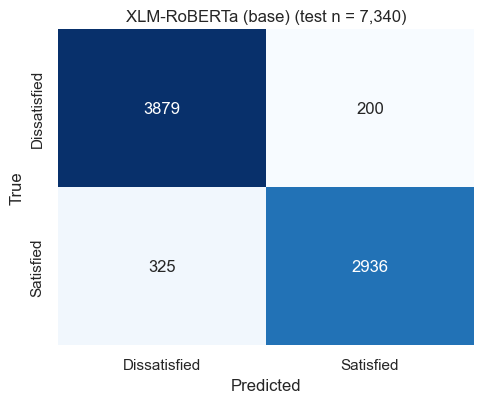

,pred_Dissatisfied,pred_Satisfied
true_Dissatisfied,3879,200
true_Satisfied,325,2936


In [9]:
cm = confusion(p.y_true, p.y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Dissatisfied", "Satisfied"], yticklabels=["Dissatisfied", "Satisfied"])
ax.set(xlabel="Predicted", ylabel="True", title=f"{config.MODEL_DISPLAY[best_overall]} (test n = {len(p):,})")
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "fig5_confusion_matrix.png", dpi=220); plt.show()
save_table(cm.reset_index().rename(columns={"index": ""}), "fig5_confusion_matrix")
cm

## Figure 6 - ROC curves

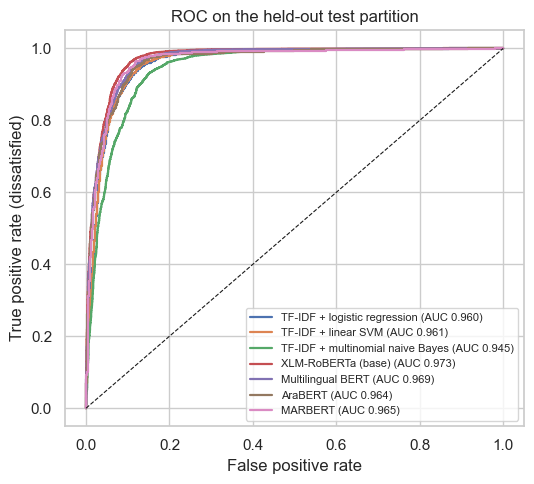

PosixPath('/Users/michaelaberra/Documents/AIML/DBA/Capstone - DA/Capstone - GIT/uae-gov-satisfaction-nlp/results/tables/fig6_auc.csv')

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
aucs = {}
for k in available:
    q = preds[k]
    y = (q.y_true == config.POSITIVE_CLASS).astype(int)
    fpr, tpr, _ = roc_curve(y, q.p_dissat)
    aucs[k] = roc_auc_score(y, q.p_dissat)
    ax.plot(fpr, tpr, lw=1.6, label=f"{config.MODEL_DISPLAY[k]} (AUC {aucs[k]:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set(xlabel="False positive rate", ylabel="True positive rate (dissatisfied)", title="ROC on the held-out test partition")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "fig6_roc_curves.png", dpi=220); plt.show()
save_table(pd.DataFrame({"model": [config.MODEL_DISPLAY[k] for k in aucs], "auc": list(aucs.values())}), "fig6_auc")

In [11]:
update_metrics("comparison", {
    "available": available, "missing": missing,
    "best_classical": best_classical, "best_overall": best_overall,
    "table12": t12.to_dict(orient="records"), "table13": t13.to_dict(orient="records"),
    "table14": t14.to_dict(orient="records"),
    "rq1": {"model": best_overall, "majority_rate": float(majority), **binom, **boot,
            "recall_dissatisfied": rep["recall_Dissatisfied"], "recall_satisfied": rep["recall_Satisfied"],
            "auc": rep["auc"], "by_length_band": by_len.to_dict(orient="records")},
    "auc": {k: float(v) for k, v in aucs.items()},
    "confusion": cm.to_dict(),
})
print("metrics updated")

metrics updated
